### **Data**

[Transactions Data Bank ⛔||⛔ Fraud Detection](https://www.kaggle.com/datasets/qusaybtoush1990/transactions-data-bank-fraud-detection?resource=download)

### **Импорт библиотек**

In [11]:
from pathlib import Path
Path.cwd()
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown, HTML
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score
import mlflow
import mlflow.catboost
from mlflow.models import infer_signature
from sklearn.metrics import f1_score
from sklearn.metrics import fbeta_score

### **Загрузка данных**

In [2]:
file_id = '1xoDH4u_CzwtpMNU3WA9-9VhwR7dZjaI4'  # из .../file/d/<ID>/view
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(url)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Date            1048574 non-null  object 
 1   nameOrig        1048574 non-null  object 
 2   amount          1048574 non-null  float64
 3   oldbalanceOrg   1048574 non-null  float64
 4   newbalanceOrig  1048574 non-null  float64
 5   City            1048574 non-null  object 
 6   type            1048574 non-null  object 
 7   Card Type       1048574 non-null  object 
 8   Exp Type        1048574 non-null  object 
 9   Gender          1048574 non-null  object 
 10  isFraud         1048574 non-null  int64  
dtypes: float64(3), int64(1), object(7)
memory usage: 88.0+ MB


**Пока из модели удалим "Date" и "nameOrig":**

In [4]:
df_new = df.copy()
df_new = df_new.drop(['Date','nameOrig'],axis=1)
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 9 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   amount          1048574 non-null  float64
 1   oldbalanceOrg   1048574 non-null  float64
 2   newbalanceOrig  1048574 non-null  float64
 3   City            1048574 non-null  object 
 4   type            1048574 non-null  object 
 5   Card Type       1048574 non-null  object 
 6   Exp Type        1048574 non-null  object 
 7   Gender          1048574 non-null  object 
 8   isFraud         1048574 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 72.0+ MB


**Сделаем one-hot encoding для всех признаков, кроме "City"**

In [5]:
df_new_encoded = pd.get_dummies(df_new, columns=['type','Card Type', 'Exp Type', 'Gender'], drop_first=True)
df_new_encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 23 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   amount                   1048574 non-null  float64
 1   oldbalanceOrg            1048574 non-null  float64
 2   newbalanceOrig           1048574 non-null  float64
 3   City                     1048574 non-null  object 
 4   isFraud                  1048574 non-null  int64  
 5   type_CASH_OUT            1048574 non-null  bool   
 6   type_DEBIT               1048574 non-null  bool   
 7   type_PAYMENT             1048574 non-null  bool   
 8   type_TRANSFER            1048574 non-null  bool   
 9   Card Type_Gold           1048574 non-null  bool   
 10  Card Type_Mass           1048574 non-null  bool   
 11  Card Type_Platinum       1048574 non-null  bool   
 12  Card Type_Signature      1048574 non-null  bool   
 13  Card Type_Silver         1048574 non-null 

**Разделим датасет на трейн и тест 70\30**

In [6]:
X = df_new_encoded.drop('isFraud', axis=1)
y = df_new_encoded['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y)

**Стандартизируем вещественные признаки:**

In [7]:
scaler = StandardScaler()

X_train[['amount','oldbalanceOrg','newbalanceOrig']] = scaler.fit_transform(X_train[['amount','oldbalanceOrg','newbalanceOrig']])
X_test[['amount','oldbalanceOrg','newbalanceOrig']] = scaler.transform(X_test[['amount','oldbalanceOrg','newbalanceOrig']])

**Далее 'City' перекодируем с помощью target encoding**

In [8]:
FEATURE = 'City'
TARGET = 'isFraud'
MIN_SAMPLES_LEAF = 50
SMOOTHING = 20

global_mean = y_train.mean()
print(f"Глобальное среднее мошенничества (для сглаживания): {global_mean:.4f}")

temp_df = X_train[[FEATURE]].copy()
temp_df[TARGET] = y_train

agg = temp_df.groupby(FEATURE)[TARGET].agg(['count', 'mean'])
agg.columns = ['counts', 'mean_target']

# применение сглаживания
agg['lambda'] = 1 / (1 + np.exp((MIN_SAMPLES_LEAF - agg['counts']) / SMOOTHING))

agg['smoothed_target'] = agg['lambda'] * agg['mean_target'] + (1 - agg['lambda']) * global_mean

city_encoding_map = agg['smoothed_target'].to_dict()

X_train[f'{FEATURE}_TargetEncoded'] = X_train[FEATURE].map(city_encoding_map).fillna(global_mean)
X_test[f'{FEATURE}_TargetEncoded'] = X_test[FEATURE].map(city_encoding_map)


X_test[f'{FEATURE}_TargetEncoded'] = X_test[f'{FEATURE}_TargetEncoded'].fillna(global_mean) #  обработка непредставленных категорий в тесте


X_train = X_train.drop(FEATURE, axis=1)
X_test = X_test.drop(FEATURE, axis=1)

print("\nTarget Encoding завершен.")
print(f"Первые 5 значений нового признака в X_train: \n{X_train[f'{FEATURE}_TargetEncoded'].head()}")

Глобальное среднее мошенничества (для сглаживания): 0.1676

Target Encoding завершен.
Первые 5 значений нового признака в X_train: 
230565    0.171145
982532    0.169802
723425    0.169234
660727    0.170948
736648    0.171145
Name: City_TargetEncoded, dtype: float64


**Финальные фичи в трейне и тесте:**

In [9]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 734001 entries, 230565 to 293268
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   amount                   734001 non-null  float64
 1   oldbalanceOrg            734001 non-null  float64
 2   newbalanceOrig           734001 non-null  float64
 3   type_CASH_OUT            734001 non-null  bool   
 4   type_DEBIT               734001 non-null  bool   
 5   type_PAYMENT             734001 non-null  bool   
 6   type_TRANSFER            734001 non-null  bool   
 7   Card Type_Gold           734001 non-null  bool   
 8   Card Type_Mass           734001 non-null  bool   
 9   Card Type_Platinum       734001 non-null  bool   
 10  Card Type_Signature      734001 non-null  bool   
 11  Card Type_Silver         734001 non-null  bool   
 12  Exp Type_Entertainment   734001 non-null  bool   
 13  Exp Type_Food            734001 non-null  bool   
 14  Exp 

---


#### **Обучение**

In [13]:
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("anomaly_detection")

c:\Users\Mi\Desktop\study\Search_for_anomalies_in_data\venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
Traceback (most recent call last):
  File "c:\Users\Mi\Desktop\study\Search_for_anomalies_in_data\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mi\Desktop\study\Search_for_anomalies_in_data\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_

<Experiment: artifact_location='file:///c:/Users/Mi/Desktop/study/Search_for_anomalies_in_data/notebooks/mlruns/567857106409021359', creation_time=1779714774410, experiment_id='567857106409021359', last_update_time=1779714774410, lifecycle_stage='active', name='anomaly_detection', tags={}, trace_location=None, workspace='default'>

##### **Бейзлайн: логистичческая регрессия**

2026/05/25 16:22:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 16:22:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


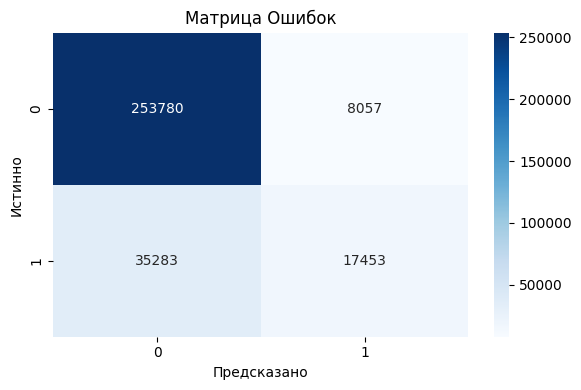

In [14]:
with mlflow.start_run(run_name="Baseline: Logistic Regression") as run:
    params = {
        "solver": "saga",
        "max_iter": 2000,
        "random_state": 42
    }

    log_reg_model = LogisticRegression(**params)
    log_reg_model.fit(X_train, y_train)
    y_pred = log_reg_model.predict(X_test)

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label=1),
        'recall': recall_score(y_test, y_pred, pos_label=1),
        'f1_score': f1_score(y_test, y_pred, pos_label=1),
        'f2_score': fbeta_score(y_test, y_pred, pos_label=1, beta=2),
        'roc_auc': roc_auc_score(y_test, log_reg_model.predict_proba(X_test)[:, 1]),
        'pr_auc': average_precision_score(y_test, log_reg_model.predict_proba(X_test)[:, 1])
    }

    # рассчёт матрицы ошибок и логирование как артефакта
    conf_matrix = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')
    ax.set_title('Матрица Ошибок')
    plt.tight_layout()
    mlflow.log_figure(fig, f"{mlflow.active_run().info.run_id}_confusion_matrix.png")

    mlflow.log_params(params)
    mlflow.log_metrics(metrics)

    mlflow.sklearn.log_model(log_reg_model, "log_reg_model")

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[253780   8057]
 [ 35283  17453]]

Отчет по классификации
              precision    recall  f1-score   support

           0       0.88      0.97      0.92    261837
           1       0.68      0.33      0.45     52736

    accuracy                           0.86    314573
   macro avg       0.78      0.65      0.68    314573
weighted avg       0.85      0.86      0.84    314573



##### ***Модель №1. Логистическая регрессия с балансировокй классов***

Полнота (recall): Модель смогла обнаружить 33% действительно фродовых операций - Это очень мало

Прецизионность (precision): Из всех транзакций, которые модель пометила как фрод, 68% действительно им являются. Т.е. модель довольно много нефродовых операций считает фродовыми


Теперь будем балансировать классы:

In [ ]:
from fastapi import params


mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("searching_anomalies/baseline")

params = {
    class_weight='balanced',
    penalty='l2',
    solver='saga',
    max_iter=2000,
    random_state=42
}

with mlflow.start_run():
        mlflow.log_params(params)
        mlflow.log_metrics()

        log_reg_balanced = LogisticRegression(**params)
        log_reg_balanced.fit(X_train, y_train)
        y_pred_balanced = log_reg_balanced.predict(X_test)

        metrics = {
            'accuracy': accuracy_score(y_test, y_pred_balanced),
            'precision': precision_score(y_test, y_pred_balanced, pos_label=1),
            'recall': recall_score(y_test, y_pred_balanced, pos_label=1),
            'f1_score': f1_score(y_test, y_pred_balanced, pos_label=1),
            'f2_score': fbeta_score(y_test, y_pred_balanced, pos_label=1, beta=2),
            'roc_auc': roc_auc_score(y_test, log_reg_balanced.predict_proba(X_test)[:, 1]),
            'pr_auc': average_precision_score(y_test, log_reg_balanced.predict_proba(X_test)[:, 1])
        }

        conf_matrix = confusion_matrix(y_test, y_pred_balanced)
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_xlabel('Предсказано')
        ax.set_ylabel('Истинно')
        ax.set_title('Матрица Ошибок')
        plt.tight_layout()
        mlflow.log_figure(fig, f"{mlflow.active_run().info.run_id}_confusion_matrix.png")

        mlflow.log_params(params)
        mlflow.log_metrics(metrics)

        mlflow.sklearn.log_model(log_reg_balanced, "log_reg_balanced")
        

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred_balanced)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred_balanced))


Матрица Ошибок
[[156201 105636]
 [  3620  49116]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.60      0.74    261837
           1       0.32      0.93      0.47     52736

    accuracy                           0.65    314573
   macro avg       0.65      0.76      0.61    314573
weighted avg       0.87      0.65      0.70    314573



##### ***Модель №2. Решающее дерево (без баласнировки классов)***

Полнота (recall): Модель смогла обнаружить 93% действительно фродовых операций - Это хорошо

Прецизионность (precision): Из всех транзакций, которые модель пометила как фрод, только 32% действительно им являются. Т.е. мы очень много нефродовых операций считаем фродом

In [ ]:
coefficients = log_reg_balanced.coef_[0]
feature_names = X_train.columns
feature_importance = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients})

print("Все Признаки")
print(feature_importance.to_string(index=False))

Все Признаки
                Признак  Коэффициент
                 amount    -0.058683
          oldbalanceOrg    -0.933963
         newbalanceOrig    -0.942472
          type_CASH_OUT     0.439283
             type_DEBIT    -1.560971
           type_PAYMENT    -2.694158
          type_TRANSFER     2.333943
         Card Type_Gold    -0.104330
         Card Type_Mass    -0.507270
     Card Type_Platinum    -0.114440
    Card Type_Signature    -0.103667
       Card Type_Silver    -0.083901
 Exp Type_Entertainment    -0.007681
          Exp Type_Food     0.017201
          Exp Type_Fuel     0.025948
       Exp Type_Grocery    -0.006847
Exp Type_Health_Fitness    -0.099647
          Exp Type_Home    -0.635822
 Exp Type_Personal_Care     0.106375
        Exp Type_Travel    -0.067597
               Gender_M    -0.005426
     City_TargetEncoded     7.523539


Город с исторически высоким уровнем мошенничества значительно повышает шансы на то что операция - фрод

TRANSFER - тоже сильный маркер, что операция фрод

***Теперь постороим дерево CART*** (без балансировки классов)

In [ ]:
# Создаём модель CART (DecisionTreeClassifier в sklearn = CART)
clf = DecisionTreeClassifier(
    criterion='gini',               # можно 'entropy', но Gini — стандарт CART
    max_depth=5,                    # ограничиваем глубину
    min_samples_split=20,           # минимум 20 объектов для разбиения
    min_samples_leaf=10,            # минимум 10 в листе
    random_state=42)

clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
y_pred = clf.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[255628   6209]
 [ 35265  17471]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.88      0.98      0.92    261837
           1       0.74      0.33      0.46     52736

    accuracy                           0.87    314573
   macro avg       0.81      0.65      0.69    314573
weighted avg       0.86      0.87      0.85    314573



##### ***Модель №3. Решающее дерево (с балансировкой классов)***

Все еще плохо - модель старается повысить точность за счет бОльшего по объему класса

***Теперь постороим дерево CART*** (с балансировкой классов)

In [ ]:
clf = DecisionTreeClassifier(
    criterion='gini',               # можно 'entropy', но Gini — стандарт CART
    max_depth=15,                    # ограничиваем глубину
    min_samples_split=20,           # минимум 20 объектов для разбиения
    min_samples_leaf=10,            # минимум 10 в листе
    class_weight='balanced',
    random_state=42)

clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,15
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [ ]:
y_pred = clf.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[186188  75649]
 [  4313  48423]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.71      0.82    261837
           1       0.39      0.92      0.55     52736

    accuracy                           0.75    314573
   macro avg       0.68      0.81      0.69    314573
weighted avg       0.88      0.75      0.78    314573



***Модель №4***

Балансировка классов и увеличение глубины дерева сдвинули фокус модели с 0-го класса, тем самым предсказывая большинство фродовых операций, но снова в ущерб ложным срабатываниям на легальных транзакций

**Следующий шаг - RANDOM FOREST**

In [ ]:
model_rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
model_rf.fit(X_train, y_train)

NameError: name 'RandomForestClassifier' is not defined

In [ ]:
y_pred = model_rf.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[255838   5999]
 [ 35604  17132]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.88      0.98      0.92    261837
           1       0.74      0.32      0.45     52736

    accuracy                           0.87    314573
   macro avg       0.81      0.65      0.69    314573
weighted avg       0.85      0.87      0.85    314573



***Модель №5***

В рандомном лесе опять выбор между recall и precision

---

Подготовка модели для сохранения. Для выполнения задания выбрана модель №4 (RandomForestClassifier)

In [ ]:
import pickle
from pathlib import Path

# мы сейчас в notebooks/, поднимаемся в корень проекта
PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "random_forest_model.pkl"

with open(MODEL_PATH, "wb") as f:
    pickle.dump(model_rf, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Модель сохранена: {MODEL_PATH}")
